In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [5]:
c200c = np.array(f["c200c"])

In [6]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [7]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [8]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_1128470/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [9]:
group_sfrs = np.log10(halos["GroupSFR"])

/tmp/ipykernel_1128470/618587702.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


In [10]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [11]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
#cent_sfrs = np.log10(cent_sfrs)

In [12]:
cent_submass = np.zeros(len(mvir))
cent_submass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloMass"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_submassx = np.log10(cent_submass*1e10)

/tmp/ipykernel_1128470/1109232107.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_submassx = np.log10(cent_submass*1e10)


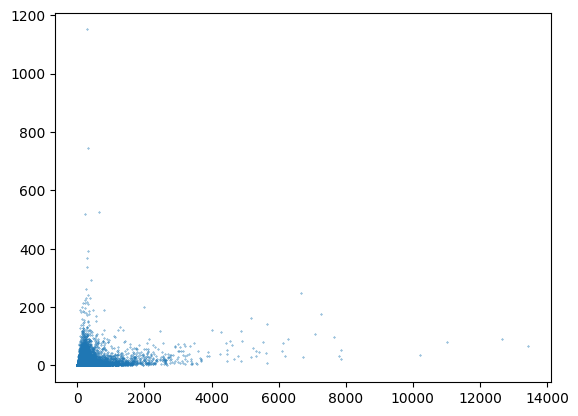

In [13]:
plt.scatter(cent_submass, cent_sfrs, s=0.1)

In [14]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [15]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [16]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [ ]:
cent_cprox = cent_vmax/cent_rmax

/tmp/ipykernel_1128470/2104352924.py:1: RuntimeWarning: invalid value encountered in divide
  cent_cprox = cent_vmax/cent_rmax


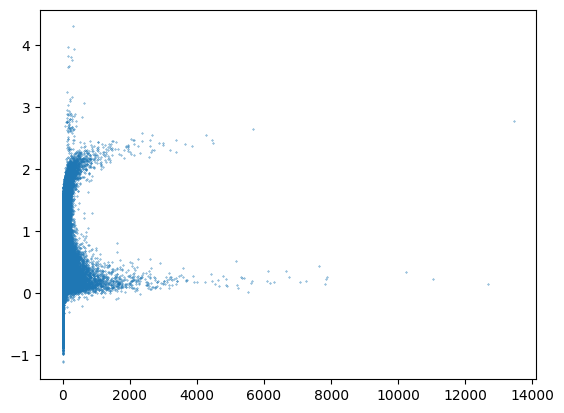

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(cent_submass, np.log10(cent_cprox), s=0.1)
plt.show()
plt.clf()

In [19]:
mask = 

SyntaxError: invalid syntax (2261587880.py, line 1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


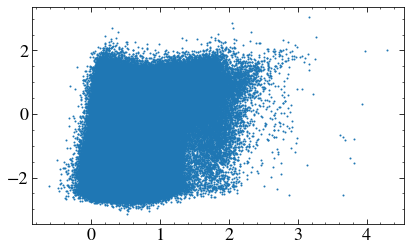

In [301]:
plt.scatter(np.log10(vmax/rmax), np.log10(subhalos["SubhaloSFR"]), s=1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


Text(0.5, 0, 'log$_{10}$M$_{\\rm vir}$ [M$_\\odot$h$^{-1}$]')

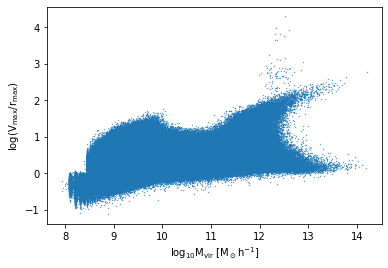

In [28]:
plt.scatter(mvir, np.log10(cent_vmax/cent_rmax), s= 0.1)
plt.ylabel(r"$\rm log (V_{max}/r_{max})$")
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


Text(0.5, 0, 'log$_{10}$M$_{\\rm vir}$ [M$_\\odot$h$^{-1}$]')

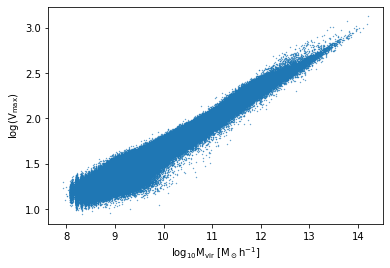

In [30]:
plt.scatter(mvir, np.log10(cent_vmax), s= 0.1)
plt.ylabel(r"$\rm log (V_{max})$")
plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")

In [294]:
logM=11
mask2 = (mvir > logM) & (mvir < logM+0.1) #& (cent_sfrs > -5) #& (np.isnan(c200c) == True)

In [295]:
plt.scatter(np.log10(c200c[mask2]), np.log10(cent_cprox[mask2]), s= 0.1)
plt.ylabel(r"$\rm log (V_{max}/r_{max})$")
plt.xlabel("log(conc)")
#plt.xlabel('log$_{10}$(SFR$_{cent}$ [M$_\odot$ yr$^{-1}$])')

NameError: name 'c200c' is not defined

In [296]:
logM =10.5

mask2 = (mvir > logM) & (mvir < logM+0.1) #& (cent_sfrs > -5) #& (np.isnan(c200c) == True)
# percentiles = np.percentile(cent_sfrs[mask2], 99)
# median = np.median(cent_sfrs[mask2])
# diff = percentiles-median
# low_lim = median-diff
# mask2 = mask2 & (cent_sfrs > low_lim)

In [297]:
stats.pearsonr(cent_sfrs[mask2],cent_cprox[mask2])

(0.23908760588201164, 0.0)

In [298]:
coef_cent = stats.spearmanr(cent_sfrs[mask2],cent_cprox[mask2])
print(coef_cent)

SpearmanrResult(correlation=0.23466949341940288, pvalue=0.0)


In [286]:
median = np.median(cent_sfrs[mask2])

In [287]:
percentiles = np.percentile(cent_sfrs[mask2], 99)
print(percentiles)

-0.8034805759586707


In [288]:
diff = percentiles-median
print(diff)

0.8937767820925342


SpearmanrResult(correlation=0.23466949341940288, pvalue=0.0)


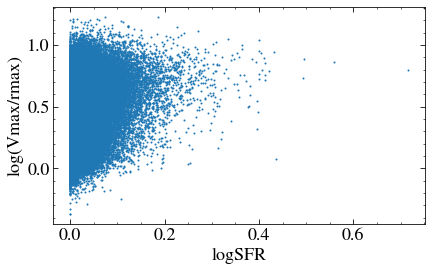

In [299]:
plt.scatter(cent_sfrs[mask2], np.log10(cent_cprox[mask2]), s=1)
#plt.vlines(median, ymin=0, ymax=2.5)
#plt.vlines(percentiles, ymin=0, ymax=2.5)
#plt.vlines(median-(percentiles-median), ymin=0, ymax=2.5)
plt.xlabel("logSFR")
plt.ylabel("log(Vmax/rmax)")
print(coef_cent)

In [201]:
logM =11
dlogM = 0.5
mask2 = (mvir > logM) & (mvir < logM+dlogM) & (cent_sfrs > -5) #& (np.isnan(c200c) == True)

In [202]:
coef_group = stats.spearmanr(group_sfrs[mask2],cent_cprox[mask2])

In [ ]:
plt.scatter( np.log10(cent_cprox[mask2]),sum_sfrs[mask2], s=1)
plt.ylabel("logSFR")
plt.xlabel("log(Vmax/rmax)")
print(coef_group)

NameError: name 'sum_sfrs' is not defined

In [18]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [19]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

[8.64899731e-01 1.59896418e+00 2.40169624e+00 5.21474013e+00
 1.98925755e+04]


Text(0.3, 0.85, 'Split by $\\rm \\tilde{V}_{max}$')

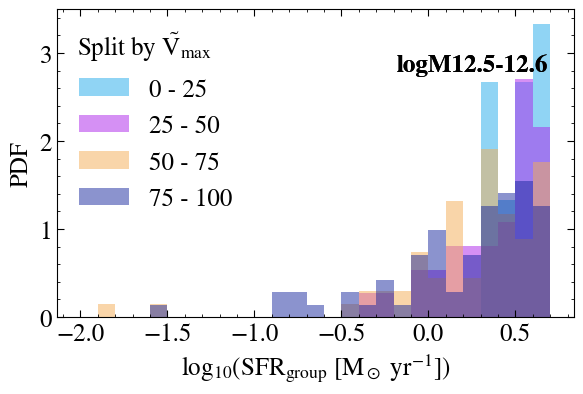

In [25]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
logM = 12.5
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i])#,histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by $\rm \tilde{V}_{max}$", (0.3,0.85), xycoords="axes fraction", ha="right")

#plt.savefig("../figures/hist_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")

[ 0.43249878  1.96619082  2.93497483  4.27317897 40.41873591]


Text(0.3, 0.85, '$\\widetilde{V}_{\\rm max}$ % bins')

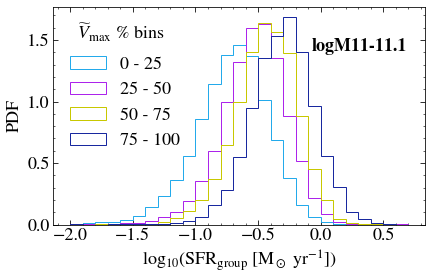

In [20]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
#color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["#23AAEB","#AC23EB","#c8c800","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
logM = 11
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")

#plt.savefig("../figures/hist_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")

[ 0.43249878  1.96619082  2.93497483  4.27317897 40.41873591]


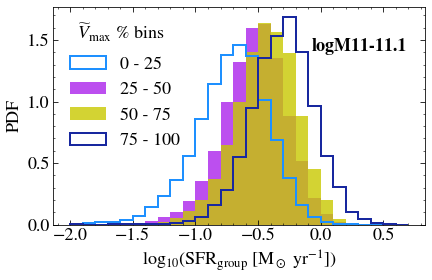

In [26]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
#color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["#23AAEB","#AC23EB","#c8c800","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["green","#AC23EB","#c8c800","#18289F"]
color_list = ["dodgerblue", "#AC23EB", "#c8c800","#18289F"]
logM = 11
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    if (i == 1) or (i == 2):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.8, color=color_list[i])# facecolor="none", edgecolor=color_list[i])
    elif (i == 0) or (i == 3):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step', linewidth=2)# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")

plt.savefig("../figures/hist_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1539: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe')
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1539: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe')
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1539: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe')


nan
nan
0.24560739
nan


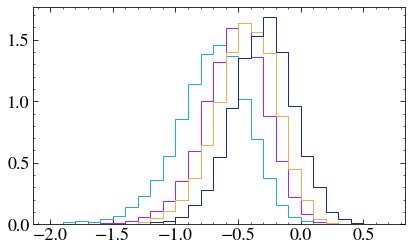

In [42]:
iqrs = []
sigmas = []
new_medians = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1]) #& (group_sfrs[mask2] > -5)
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
    ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
    iqr = ps[1] - ps[0]
    iqrs.append(iqr)
    print(np.nanstd(group_sfrs[mask2][mask]))
    med = np.median(group_sfrs[mask2][mask])
    new_medians.append(med)

In [21]:
logMs = np.arange(11,14, 0.1)

In [22]:

nbins = len(logMs)


new_medians_arr = np.zeros((4,nbins), dtype=float)
new_iqrs_arr = np.zeros((4,nbins), dtype=float)

orig_iqrs = []
orig_medians = []

for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    
    percentile_list = [0, 25, 50, 75, 100]
    percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)
    
    ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
    iqr = ps[1] - ps[0]
    orig_iqrs.append(iqr)
    
    med = np.nanpercentile(group_sfrs[mask2], q=[50])
    orig_medians.append(med)
    
    iqrs = []
    sigmas = []
    new_medians = []
    for ip, percentile in enumerate(percentiles[:4]):
        mask = (cent_cprox[mask2] > percentiles[ip]) & (cent_cprox[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
        masks.append(mask)
        #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
        ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
        #print(logM)
        #print(ps)
        
        iqr = ps[1] - ps[0]
        iqrs.append(iqr)
        #print(np.nanstd(group_sfrs[mask2][mask]))
        med = np.nanmedian(group_sfrs[mask2][mask])
        new_medians.append(med)
        new_medians_arr[ip][ibin] = med
        new_iqrs_arr[ip][ibin] = iqr

NameError: name 'masks' is not defined

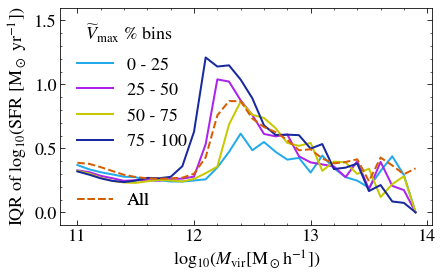

In [208]:

for ip in range(4):
    plt.plot(logMs, new_iqrs_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip], linewidth=2)

    

plt.plot(logMs, orig_iqrs, color=palette_tab10[3] , linestyle="dashed", label="All")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles=handles[:-1],loc="upper left", bbox_to_anchor=(0,0.85))
ax.add_artist(leg)
leg = ax.legend(handles=handles[-1:], loc="lower left")
ax.add_artist(leg)  

plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.annotate("IQR of each"+ "\n" + r"$\widetilde{V}_{\rm max}$ bin", (0.7,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-0.1,1.6)
#plt.savefig("../figures/iqr_conc_proxy.pdf", format="pdf", bbox_inches="tight")

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_602699/3593719650.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


(-1.0, 3.1)

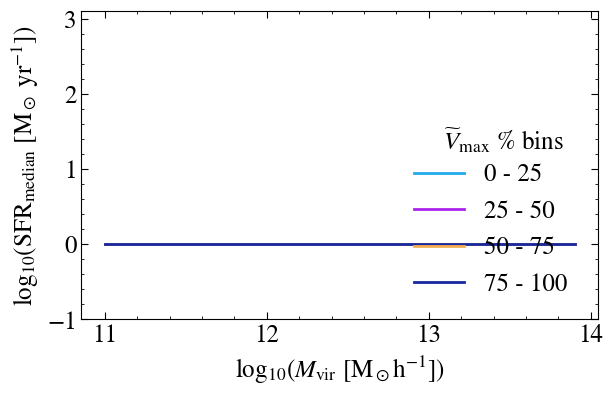

In [26]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip],linewidth=2)
    

#plt.plot(logMs, orig_medians, color=palette_tab10[3] , linestyle="dashed")
    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$\widetilde{V}_{\rm max}$ % bins", (0.7,0.55), xycoords="axes fraction", ha="left")

#plt.annotate("Median of each"+ "\n" + r"$\widetilde{V}_{\rm max}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)
#plt.savefig("../figures/median_conc_proxy.pdf", format="pdf", bbox_inches="tight")

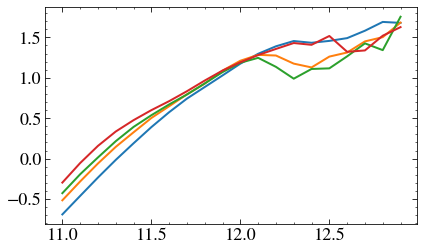

In [59]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip])
    


In [45]:
print(np.median(group_sfrs[mask2]))

-0.47942188


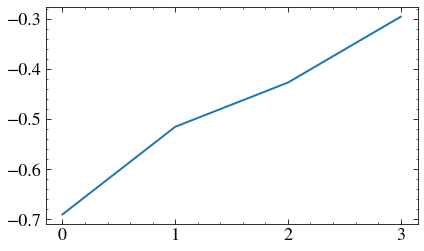

In [43]:
plt.plot(new_medians)

In [35]:
np.nanstd(group_sfrs[mask2 & (group_sfrs > -5)])

0.30070716

In [40]:
ps = np.percentile(group_sfrs[mask2], q=[25,75])
iqr = ps[1] - ps[0]
print(iqr)

0.3876328766345978


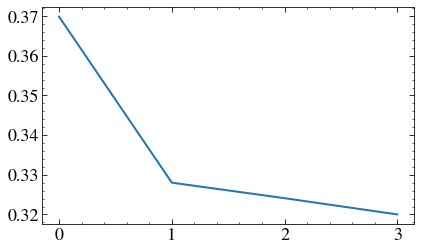

In [41]:
plt.plot(iqrs)

[ 0.43249878  1.96619082  2.93497483  4.27317897 40.41873591]


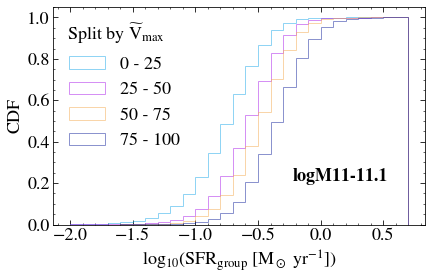

In [272]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
logM = 11
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, cumulative=True,label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"CDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.2), xycoords="axes fraction", ha="right", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by $\rm \widetilde{V}_{max}$", (0.3,0.85), xycoords="axes fraction", ha="right")

#plt.savefig("../figures/cdf_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")

In [159]:
coef_mvir = stats.spearmanr(group_sfrs[mask2],mvir[mask2])

SpearmanrResult(correlation=0.23971707267090106, pvalue=0.0)


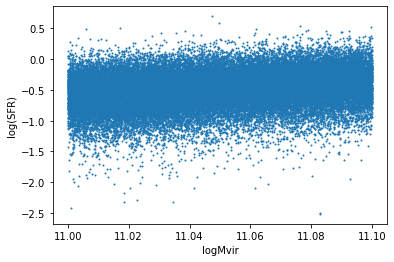

In [160]:
plt.scatter(mvir[mask2], group_sfrs[mask2], s=1)
plt.xlabel("logMvir")
plt.ylabel("log(SFR)")
print(coef_mvir)

In [98]:
np.sum(mask2)

9

In [122]:
odir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all/mvir/ihalo"
with open(f"{odir}/cent_vmax_conc_proxy_logM10.txt", "w") as f:
    print("# ihalo, vmax/rmax", file=f)
    for ihalo in range(len(halos["GroupFirstSub"])):
        if mvir[ihalo] >= 10:
            print(ihalo, cent_cprox[ihalo], file=f)